In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mpl
import seaborn as sns

birds = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Personal_projects/Bird families/All_birds.csv', encoding='latin-1')
birds.describe()


,sort_v2024,extinct,sort_v2023
count,33127.000000,33127.000000,32846.000000
mean,17937.964075,0.006973,17778.508884
std,10169.001428,0.083215,10099.541930
min,1.000000,0.000000,1.000000
25%,9269.500000,0.000000,9153.250000
50%,17992.000000,0.000000,17827.500000
75%,26705.500000,0.000000,26489.750000
max,35560.000000,1.000000,35289.000000


In [ ]:
birds.head()

,sort_v2024,species_code,Clements v2024b change,text for website v2024b,category,English_name,scientific name,range,genus,order,family_latin,family_english,extinct,extinct year,sort_v2023
0,1.0,struth1,NaN,NaN,family,Ostriches,Struthionidae,NaN,Struthionidae,Struthioniformes,Struthionidae,Ostriches,0,NaN,1.0
1,2.0,ostric2,NaN,NaN,species,Common Ostrich,Struthio camelus,NaN,Struthio,Struthioniformes,Struthionidae,Ostriches,0,NaN,2.0
2,3.0,comost1,NaN,NaN,subspecies,Common Ostrich,Struthio camelus camelus,Sahel of North Africa and the Sudan,Struthio,Struthioniformes,Struthionidae,Ostriches,0,NaN,3.0
3,4.0,comost2,NaN,NaN,subspecies,Common Ostrich,Struthio camelus syriacus,formerly Syrian and Arabian desert; extinct ca...,Struthio,Struthioniformes,Struthionidae,Ostriches,1,1966,4.0
4,5.0,comost3,NaN,NaN,subspecies,Common Ostrich,Struthio camelus massaicus,southern Kenya and eastern Tanzania,Struthio,Struthioniformes,Struthionidae,Ostriches,0,NaN,5.0


In [ ]:
birds.isnull().sum()
## these nulls were put in by myself as previously they were blank spaces.

,0
sort_v2024,0
species_code,0
Clements v2024b change,31439
text for website v2024b,31644
category,0
English_name,0
scientific name,0
range,6736
genus,0
order,0


Working with the data

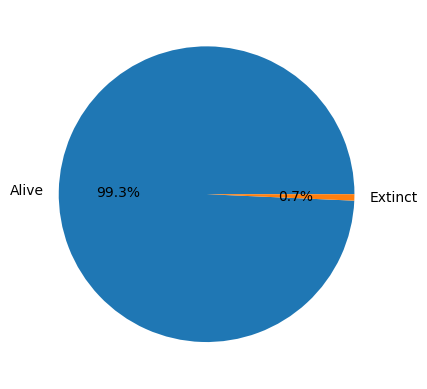

In [3]:
extinction_prop = birds['extinct'].value_counts()
extinction_prop

fig, ax = mpl.subplots(1,1)
labels = 'Alive','Extinct'
ax.pie(extinction_prop, labels = labels, autopct='%1.1f%%')
mpl.show()

# Looking at extinct species in more depth

In [4]:
Extinct_spp = birds[birds['extinct'] == 1]
Extinct_spp

,sort_v2024,species_code,Clements v2024b change,text for website v2024b,category,English_name,scientific name,range,genus,order,family_latin,family_english,extinct,extinct year,sort_v2023
3,4.0,comost2,NaN,NaN,subspecies,Common Ostrich,Struthio camelus syriacus,formerly Syrian and Arabian desert; extinct ca...,Struthio,Struthioniformes,Struthionidae,Ostriches,1,1966,4.0
15,15.0,emu3,NaN,NaN,subspecies,Emu,Dromaius novaehollandiae baudinianus,formerly Kangaroo Island (South Australia); ex...,Dromaius,Casuariiformes,Casuariidae,Cassowaries and Emu,1,1836,209.0
16,16.0,emu4,NaN,NaN,subspecies,Emu,Dromaius novaehollandiae minor,"formerly King Island (Tasmania); extinct, last...",Dromaius,Casuariiformes,Casuariidae,Cassowaries and Emu,1,1850,210.0
17,17.0,emu5,NaN,NaN,subspecies,Emu,Dromaius novaehollandiae diemenensis,formerly Tasmania; extinct ca. 1865,Dromaius,Casuariiformes,Casuariidae,Cassowaries and Emu,1,1865,211.0
319,406.0,maushe1,NaN,NaN,species,Mauritius Shelduck,Alopochen mauritiana,"formerly Mauritius; extinct, likely since late...",Alopochen,Anseriformes,Anatidae,"Ducks, Geese, and Waterfowl",1,xxxx,398.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30732,32944.0,dusspa1,NaN,NaN,group (monotypic),Seaside Sparrow (Dusky),Ammospiza maritima nigrescens,formerly saltmarshes of eastern coastal and ea...,Ammospiza,Passeriformes,Passerellidae,New World Sparrows,1,1983,32697.0
30887,33115.0,spotow11,NaN,NaN,subspecies,Spotted Towhee (oregonus Group),Pipilo maculatus consobrinus,formerly Isla Guadalupe (off western Baja Cali...,Pipilo,Passeriformes,Passerellidae,New World Sparrows,1,1897,32867.0
30912,33145.0,bertow1,NaN,NaN,species,Bermuda Towhee,Pipilo naufragus,"formerly Bermuda; extinct, apparently survived...",Pipilo,Passeriformes,Passerellidae,New World Sparrows,1,1611,32897.0
31206,33465.0,jamori2,NaN,NaN,subspecies,Jamaican Oriole,Icterus leucopteryx bairdi,formerly Grand Cayman; extinct ca. 1967,Icterus,Passeriformes,Icteridae,Troupials and Allies,1,1967,33215.0


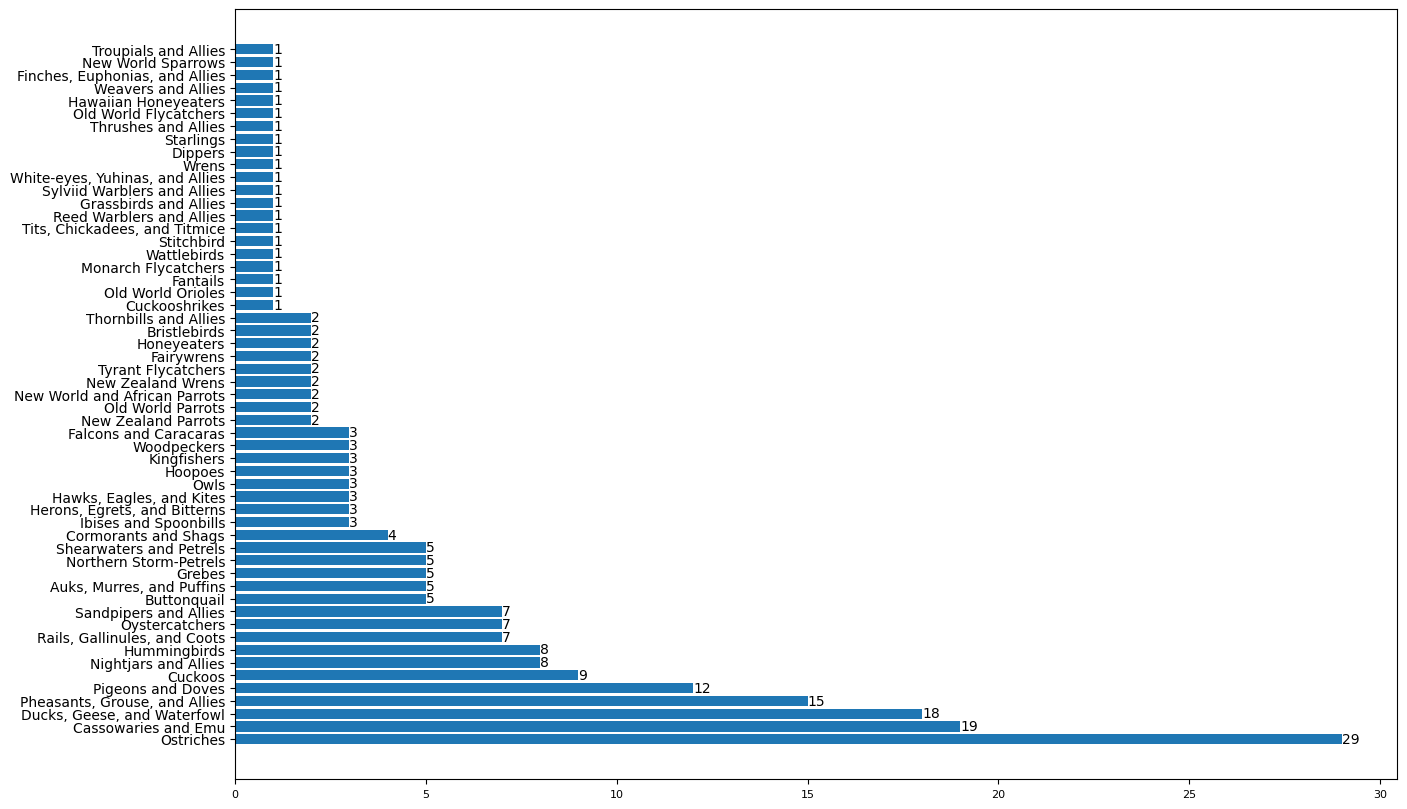

In [ ]:
fig, ax = mpl.subplots()

ax.barh(Extinct_spp['family_english'].unique(), Extinct_spp['family_english'].value_counts())
ax.bar_label(ax.containers[0], label_type='edge') ## adds the values of the bars
mpl.gcf().set_size_inches(15, 10)
mpl.xticks(fontsize=8)
mpl.show()

<function matplotlib.pyplot.show(close=None, block=None)>

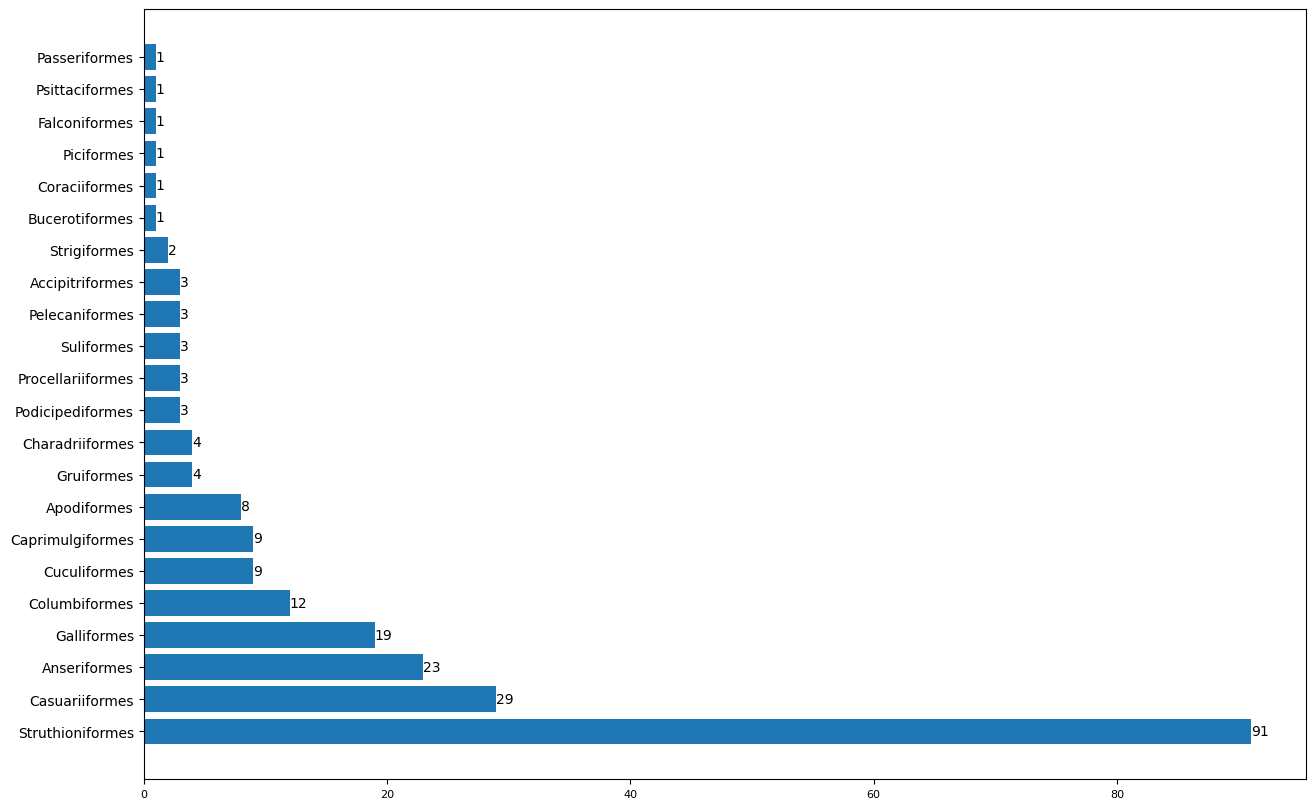

In [ ]:
## what about the orders they belong to
fig, ax = mpl.subplots()
ax.barh(Extinct_spp['order'].unique(), Extinct_spp['order'].value_counts())
ax.bar_label(ax.containers[0], label_type='edge')
mpl.gcf().set_size_inches(15, 10)
mpl.xticks(fontsize=8)
mpl.show

In [20]:
## when did species go extinct?
Extinct_spp_year = Extinct_spp.sort_values('extinct year', ascending = True)

values_to_remove = ['1500s', '1730s','1860s','1930s', 'late 1970s', 'xxxx', '1870s']
## need to clean this as not all values are integers as some are vague times
Extinct_spp_year = Extinct_spp_year[~Extinct_spp_year['extinct year'].isin(values_to_remove)]
Extinct_spp_year


,sort_v2024,species_code,Clements v2024b change,text for website v2024b,category,English_name,scientific name,range,genus,order,family_latin,family_english,extinct,extinct year,sort_v2023
8517,9513.0,sthhoo1,NaN,NaN,species,St. Helena Hoopoe,Upupa antaios,formerly St. Helena Island; extinct,Upupa,Bucerotiformes,Upupidae,Hoopoes,1,1502,9405.0
5012,5542.0,sthrai1,NaN,NaN,species,St. Helena Crake,Zapornia astrictocarpus,formerly St. Helena Island; extinct,Zapornia,Gruiformes,Rallidae,"Rails, Gallinules, and Coots",1,1502,5572.0
4758,5270.0,sthcra1,name change - sciname,Move monotypic St. Helena Rail Atlantisia poda...,species,St. Helena Rail,Aphanocrex podarces,formerly St. Helena Island; extinct,Aphanocrex,Gruiformes,Rallidae,"Rails, Gallinules, and Coots",1,1502,5300.0
6246,7025.0,lshpet1,NaN,NaN,species,Large St. Helena Petrel,Pterodroma rupinarum,formerly bred on St. Helena Island; extinct,Pterodroma,Procellariiformes,Procellariidae,Shearwaters and Petrels,1,1502,6942.0
6309,7101.0,sshpet1,NaN,NaN,species,Small St. Helena Petrel,Bulweria bifax,formerly St. Helena Island; extinct,Bulweria,Procellariiformes,Procellariidae,Shearwaters and Petrels,1,1502,7015.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18617,20128.0,ruffan5,NaN,NaN,group (monotypic),Micronesian Rufous Fantail (Guam),Rhipidura versicolor uraniae,formerly Guam (Mariana Islands); extinct,Rhipidura,Passeriformes,Rhipiduridae,Fantails,1,1984,19966.0
6041,6780.0,atigre1,NaN,NaN,species,Atitlan Grebe,Podilymbus gigas,"formerly Lake Atitlan, southwestern Guatemala;...",Podilymbus,Podicipediformes,Podicipedidae,Grebes,1,1986,1835.0
27602,29623.0,kauoo,NaN,NaN,species,Kauai Oo,Moho braccatus,"formerly Kauai; extinct, last reported 1987",Moho,Passeriformes,Mohoidae,Hawaiian Honeyeaters,1,1987,29391.0
15500,16878.0,verfly8,NaN,NaN,group (monotypic),Brujo Flycatcher (San Cristobal),Pyrocephalus nanus dubius,formerly San Cristóbal Island (Galapagos); ext...,Pyrocephalus,Passeriformes,Tyrannidae,Tyrant Flycatchers,1,1987,16734.0


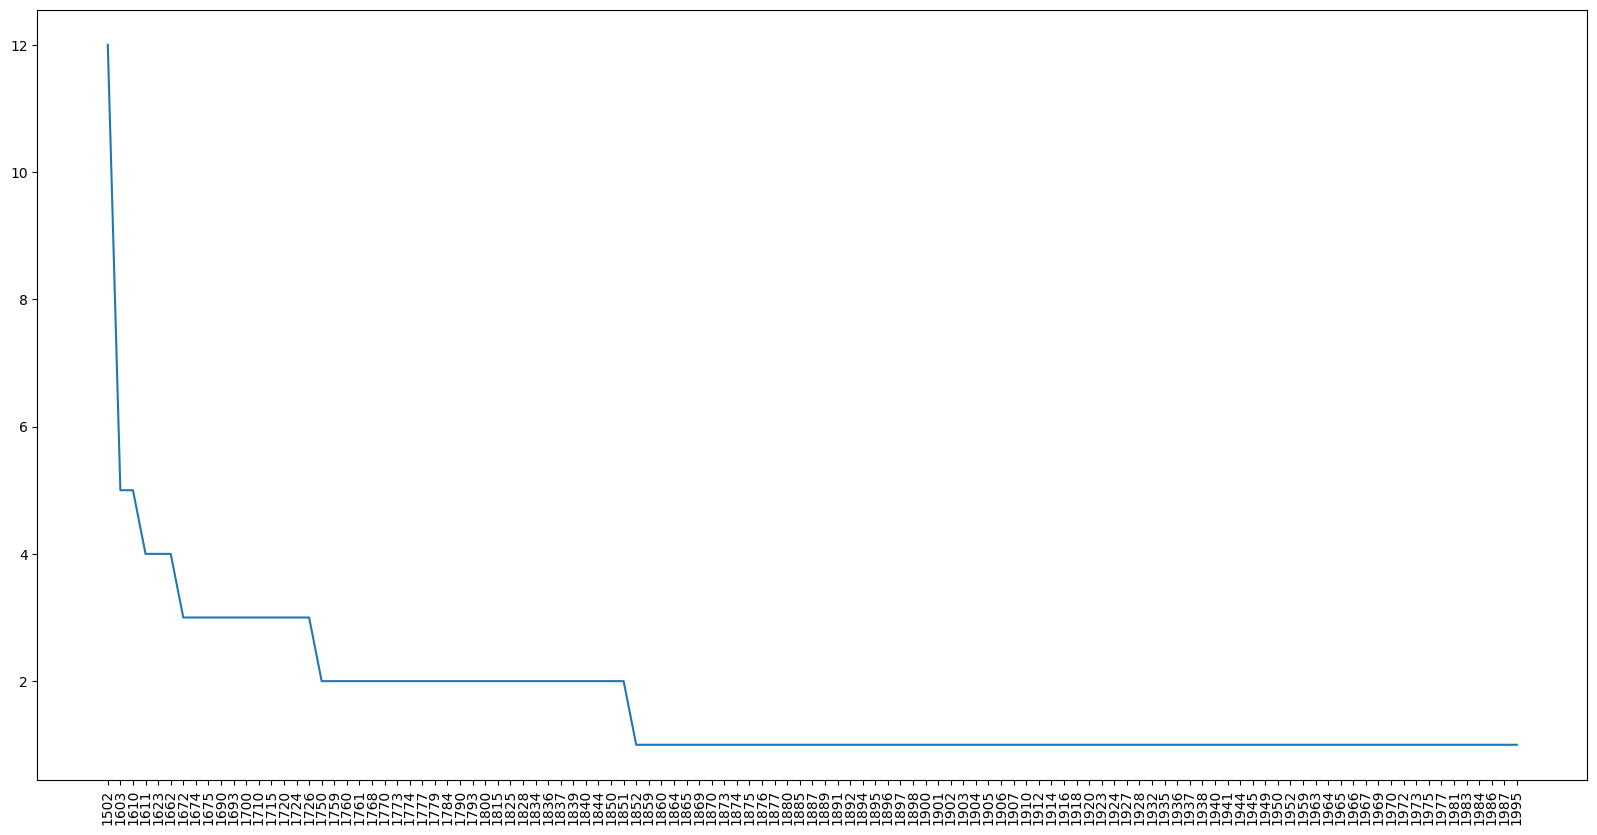

In [21]:
mpl.plot(Extinct_spp_year['extinct year'].unique(), Extinct_spp_year['extinct year'].value_counts())
mpl.gcf().set_size_inches(20,10)
mpl.xticks(rotation=90)
mpl.show()
## most went extinct long ago